<a href="https://colab.research.google.com/github/rfortuna98/QNC-Fall-2025/blob/main/Ex_Phe_Coc_Fem_Ch1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Animal Treatment  Body_Weight  Lever_Presses
0       2       0ug          390            117
1       2       3ug          385             23
2       2      10ug          385             16
3       6       0ug          285            100
4       6       3ug          290            115
5       6      10ug          285             74
6       8       0ug          310            105
7       8       3ug          311             95
8       8      10ug          300             81
9       9       0ug          315             70
10      9       3ug          304             54
11      9      10ug          308              0
12     10       0ug          293             93
13     10       3ug          300             90
14     10      10ug          308             34


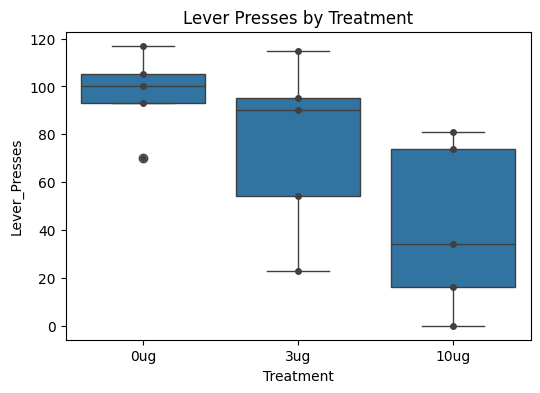

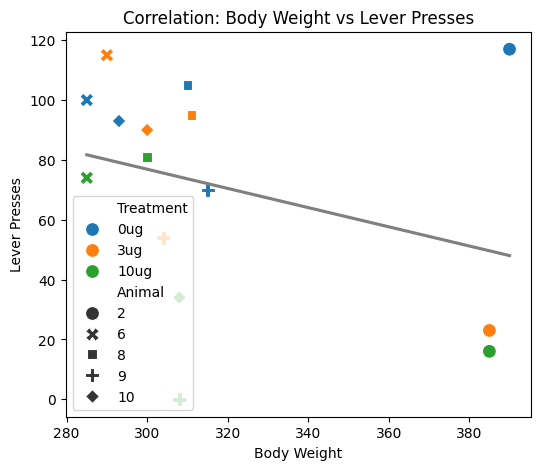

Pearson correlation: r = -0.32, p = 0.253


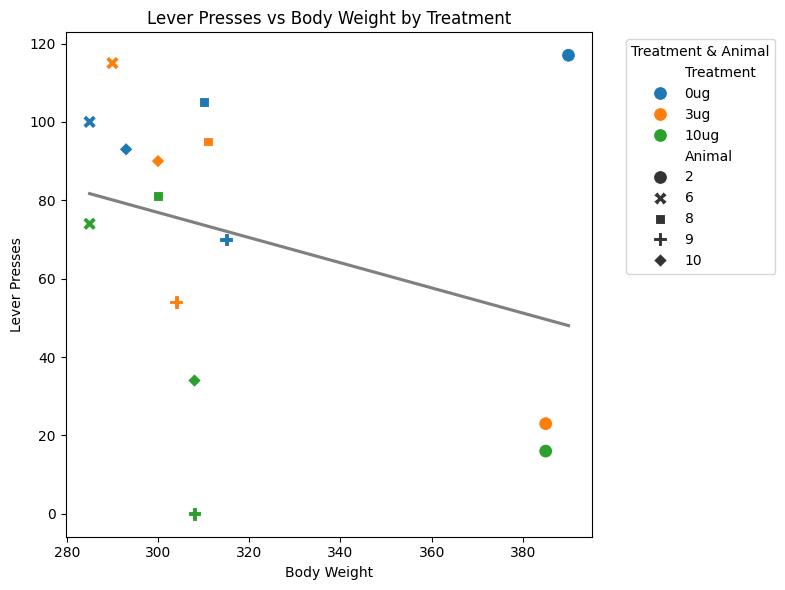

In [1]:
import pandas as pd

# Animals and treatments
animals = ['2', '6', '8', '9', '10']
treatments = ['0ug', '3ug', '10ug']

# Body weights and lever presses (1 measurement per treatment)
body_weights = [
    [390, 385, 385],  # animal 2
    [285, 290, 285],  # animal 6
    [310, 311, 300],  # animal 8
    [315, 304, 308],  # animal 9
    [293, 300, 308]   # animal 10
]

lever_presses = [
    [117, 23, 16],  # animal 2
    [100, 115, 74],  # animal 6
    [105, 95, 81],  # animal 8
    [70, 54, 0],  # animal 9
    [93, 90, 34]   # animal 10
]

# Convert to long-format DataFrame
rows = []
for i, animal in enumerate(animals):
    for j, treatment in enumerate(treatments):
        rows.append({
            'Animal': animal,
            'Treatment': treatment,
            'Body_Weight': body_weights[i][j],
            'Lever_Presses': lever_presses[i][j]
        })

df = pd.DataFrame(rows)
print(df)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Treatment', y='Lever_Presses')
sns.swarmplot(data=df, x='Treatment', y='Lever_Presses', color=".25")
plt.title('Lever Presses by Treatment')
plt.show()

import matplotlib.pyplot as plt

import seaborn as sns
from scipy.stats import pearsonr

# Scatter plot
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='Body_Weight', y='Lever_Presses', hue='Treatment', style='Animal', s=100)
sns.regplot(data=df, x='Body_Weight', y='Lever_Presses', scatter=False, ci=None, color='gray')  # regression line
plt.title('Correlation: Body Weight vs Lever Presses')
plt.xlabel('Body Weight')
plt.ylabel('Lever Presses')
plt.show()

# Calculate Pearson correlation
corr, p_value = pearsonr(df['Body_Weight'], df['Lever_Presses'])
print(f"Pearson correlation: r = {corr:.2f}, p = {p_value:.3f}")


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Body_Weight',
    y='Lever_Presses',
    hue='Treatment',       # color by treatment
    style='Animal',        # marker shape by animal
    s=100                  # size of points
)

# Optional: add regression line (overall)
sns.regplot(
    data=df,
    x='Body_Weight',
    y='Lever_Presses',
    scatter=False,
    ci=None,
    color='gray'
)

plt.title('Lever Presses vs Body Weight by Treatment')
plt.xlabel('Body Weight')
plt.ylabel('Lever Presses')
plt.legend(title='Treatment & Animal', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

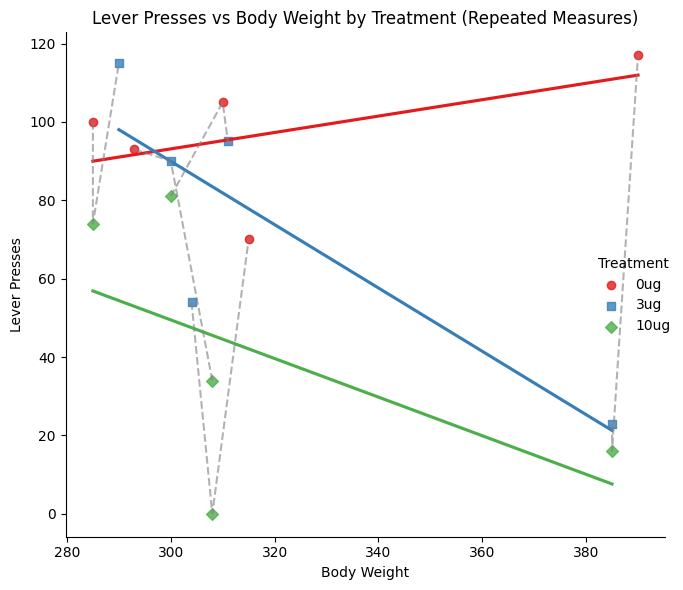

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

# Scatter points and regression lines per treatment
sns.lmplot(
    data=df,
    x='Body_Weight',
    y='Lever_Presses',
    hue='Treatment',
    markers=['o','s','D'],     # different shapes for treatments
    palette='Set1',
    ci=None,
    height=6,
    aspect=1
)

# Connect repeated measures for each animal
for animal in df['Animal'].unique():
    animal_data = df[df['Animal'] == animal].sort_values('Body_Weight')
    plt.plot(
        animal_data['Body_Weight'],
        animal_data['Lever_Presses'],
        color='gray',
        linestyle='--',
        alpha=0.6
    )

plt.title('Lever Presses vs Body Weight by Treatment (Repeated Measures)')
plt.xlabel('Body Weight')
plt.ylabel('Lever Presses')
plt.tight_layout()
plt.show()

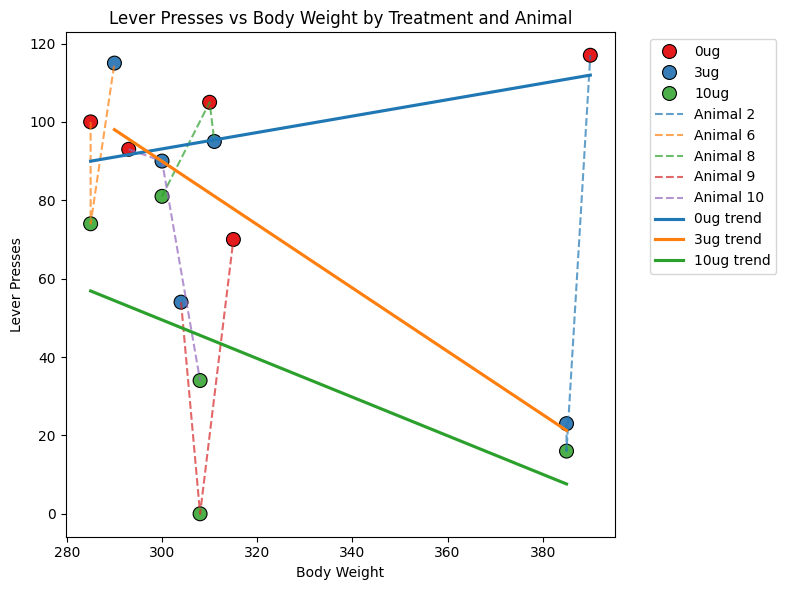

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

# Scatter points: colored by Treatment
sns.scatterplot(
    data=df,
    x='Body_Weight',
    y='Lever_Presses',
    hue='Treatment',
    palette='Set1',
    s=100,
    edgecolor='black',
    legend='full'
)

# Connect repeated measures per animal: colored by Animal
animals = df['Animal'].unique()
palette_animals = sns.color_palette("tab10", len(animals))

for i, animal in enumerate(animals):
    animal_data = df[df['Animal'] == animal].sort_values('Body_Weight')
    plt.plot(
        animal_data['Body_Weight'],
        animal_data['Lever_Presses'],
        color=palette_animals[i],
        linestyle='--',
        alpha=0.7,
        label=f"Animal {animal}"
    )

# Optional: separate regression lines per treatment
for treatment in df['Treatment'].unique():
    treatment_data = df[df['Treatment'] == treatment]
    sns.regplot(
        data=treatment_data,
        x='Body_Weight',
        y='Lever_Presses',
        scatter=False,
        ci=None,
        label=f"{treatment} trend",
        line_kws={'linestyle':'-'}
    )

plt.xlabel('Body Weight')
plt.ylabel('Lever Presses')
plt.title('Lever Presses vs Body Weight by Treatment and Animal')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [4]:
import pandas as pd
import numpy as np

# Create weight bins (e.g., 280-300, 300-320, 320-340, etc.)
bins = [280, 300, 320, 340, 360, 400]
labels = ['280-300','300-320','320-340','340-360','360-400']
df['Weight_Bin'] = pd.cut(df['Body_Weight'], bins=bins, labels=labels)

# Group by weight bin and calculate mean and variance of lever presses
variance_df = df.groupby('Weight_Bin')['Lever_Presses'].agg(['mean', 'var', 'std', 'count']).reset_index()
print(variance_df)


  Weight_Bin       mean          var        std  count
0    280-300  92.166667   208.566667  14.441837      6
1    300-320  59.666667  1532.266667  39.144178      6
2    320-340        NaN          NaN        NaN      0
3    340-360        NaN          NaN        NaN      0
4    360-400  52.000000  3181.000000  56.400355      3


/tmp/ipython-input-1186366516.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  variance_df = df.groupby('Weight_Bin')['Lever_Presses'].agg(['mean', 'var', 'std', 'count']).reset_index()


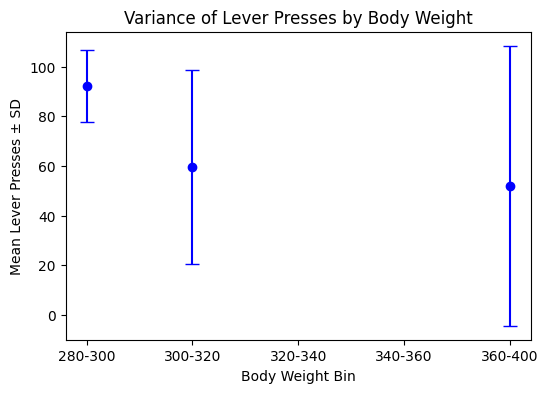

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.errorbar(
    variance_df['Weight_Bin'],
    variance_df['mean'],
    yerr=variance_df['std'],
    fmt='o',
    capsize=5,
    color='blue'
)
plt.xlabel('Body Weight Bin')
plt.ylabel('Mean Lever Presses ± SD')
plt.title('Variance of Lever Presses by Body Weight')
plt.show()


In [6]:
from scipy.stats import pearsonr, spearmanr

# Pearson correlation (linear relationship)
r, p = pearsonr(df['Body_Weight'], df['Lever_Presses'])
print(f"Pearson correlation: r = {r:.2f}, p = {p:.3f}")

# Spearman correlation (monotonic relationship)
rho, p_s = spearmanr(df['Body_Weight'], df['Lever_Presses'])
print(f"Spearman correlation: rho = {rho:.2f}, p = {p_s:.3f}")


Pearson correlation: r = -0.32, p = 0.253
Spearman correlation: rho = -0.23, p = 0.418


In [7]:
import statsmodels.api as sm

# Predictor (body weight)
X = df['Body_Weight']
X = sm.add_constant(X)  # adds intercept
y = df['Lever_Presses']

# Fit linear regression
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          Lever_Presses   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     1.433
Date:                Fri, 31 Oct 2025   Prob (F-statistic):              0.253
Time:                        20:10:05   Log-Likelihood:                -74.317
No. Observations:                  15   AIC:                             152.6
Df Residuals:                      13   BIC:                             154.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         173.1256     85.736      2.019      

In [8]:
import statsmodels.formula.api as smf

# Mixed-effects: Animal as random effect
model = smf.mixedlm("Lever_Presses ~ Body_Weight", df, groups=df["Animal"])
result = model.fit()
print(result.summary())


           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Lever_Presses
No. Observations: 15      Method:             REML         
No. Groups:       5       Scale:              1261.9899    
Min. group size:  3       Log-Likelihood:     -71.5667     
Max. group size:  3       Converged:          Yes          
Mean group size:  3.0                                      
-----------------------------------------------------------
               Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept     171.276   95.300  1.797 0.072 -15.509 358.062
Body_Weight    -0.315    0.298 -1.057 0.290  -0.899   0.269
Group Var     138.637   14.601                             

